In [32]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score

In [5]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df=pd.DataFrame(data=housing.data, columns=housing.feature_names)
df['Prediction']=housing.target

In [6]:
df.sample(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Prediction
9087,5.7049,9.0,6.699571,1.085837,731.0,3.137339,34.66,-118.17,1.732
11765,4.4850,10.0,6.434129,1.032714,3507.0,3.100796,38.72,-121.25,1.794
19210,2.9050,41.0,4.310044,1.052402,965.0,2.106987,38.46,-122.71,1.593
6924,3.7986,38.0,5.357995,1.059666,1540.0,3.675418,34.01,-118.07,1.710
14354,3.1389,23.0,4.052013,1.095638,1275.0,2.139262,32.75,-117.23,1.018
19107,2.1696,16.0,4.834921,0.977778,477.0,1.514286,38.27,-122.66,0.750
1272,4.8958,17.0,7.348315,1.089888,825.0,3.089888,37.91,-121.70,1.871
3205,2.6145,10.0,5.116992,1.022284,1864.0,2.596100,36.35,-119.62,0.803
2245,2.2215,15.0,5.352472,1.106858,1232.0,1.964912,36.83,-119.79,0.722
7844,3.0909,31.0,4.402778,1.046875,2625.0,4.557292,33.90,-118.18,1.509


In [8]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Prediction    0
dtype: int64

In [12]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
20635    False
20636    False
20637    False
20638    False
20639    False
Length: 20640, dtype: bool

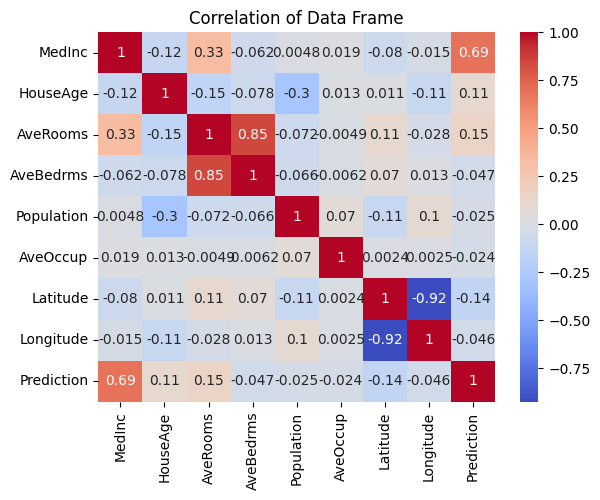

In [15]:
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation of Data Frame")
plt.show()

In [16]:
df.drop('AveOccup',axis=1,inplace=True)

In [17]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'Latitude',
       'Longitude', 'Prediction'],
      dtype='object')

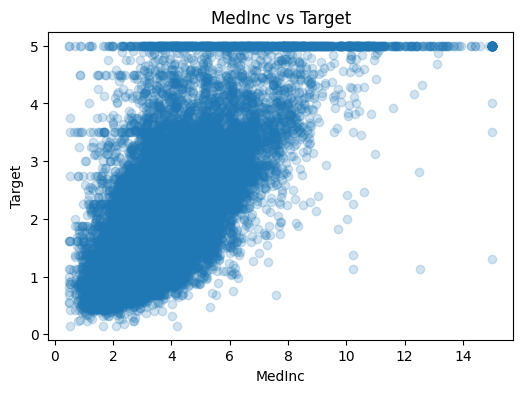

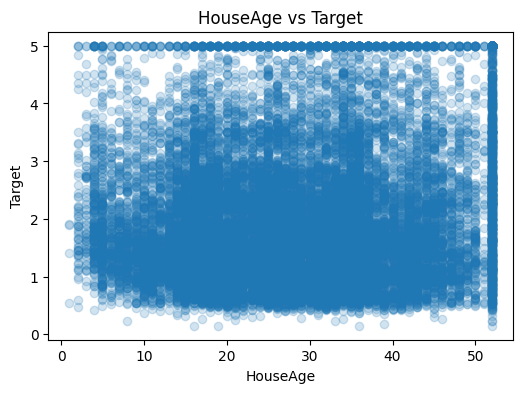

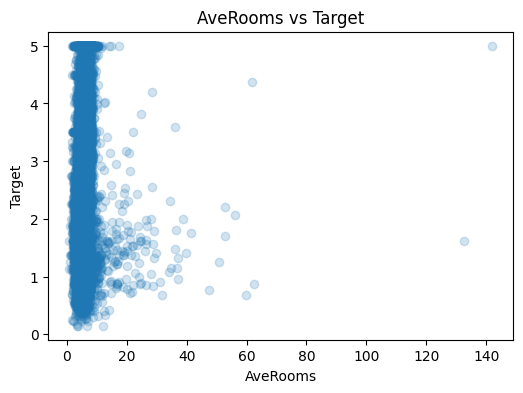

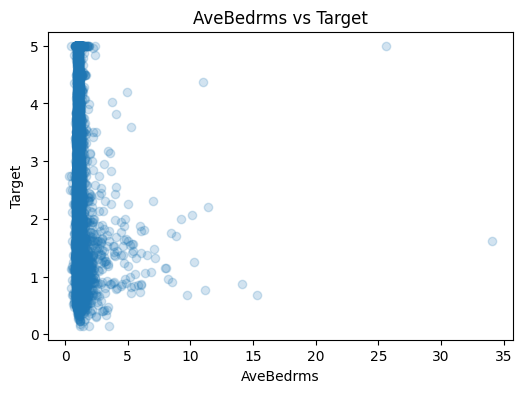

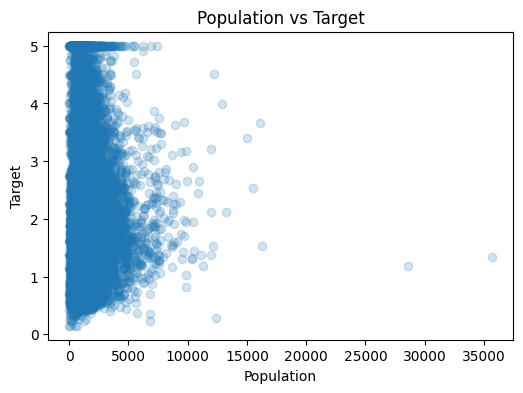

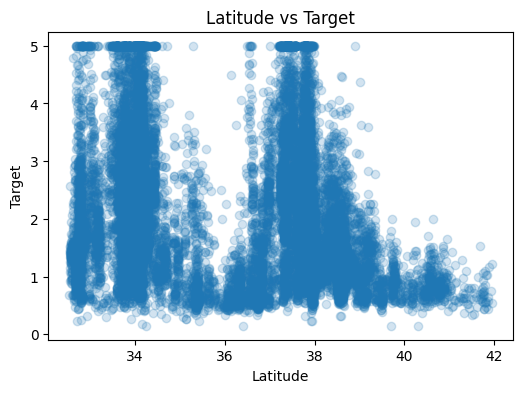

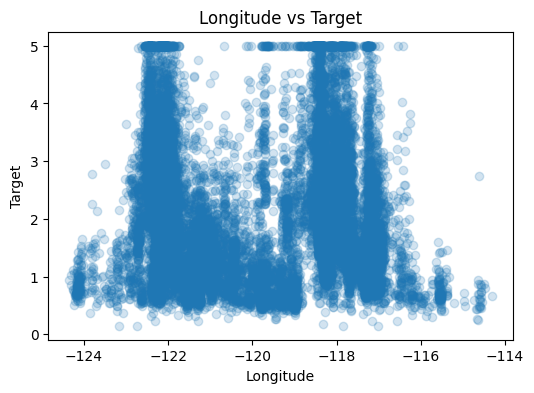

In [22]:
for column in df.columns:
    if column != "Prediction":
     plt.figure(figsize=(6, 4))
     plt.scatter(df[column], df["Prediction"], alpha=0.2)
     plt.xlabel(column)
     plt.ylabel("Target")
     plt.title(f"{column} vs Target")
     plt.show()

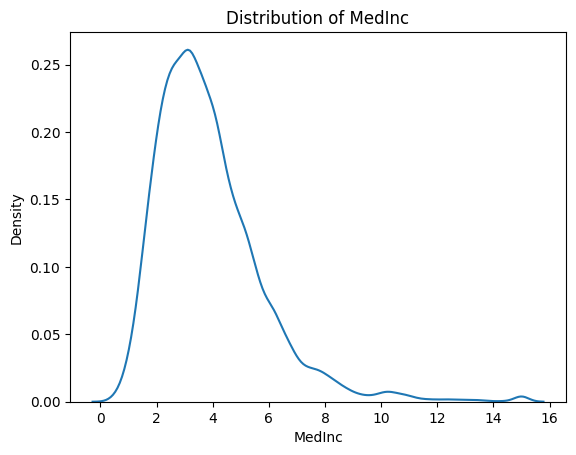

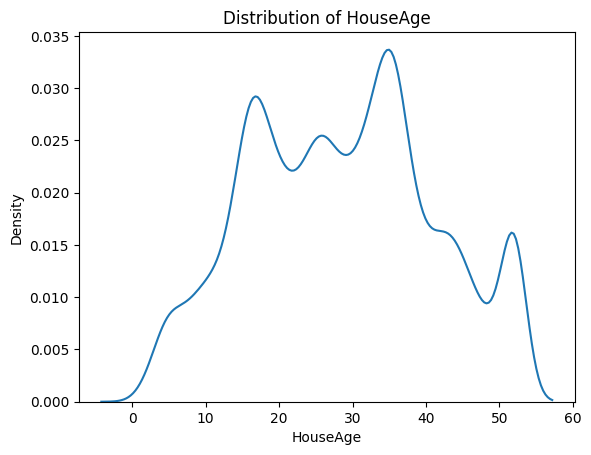

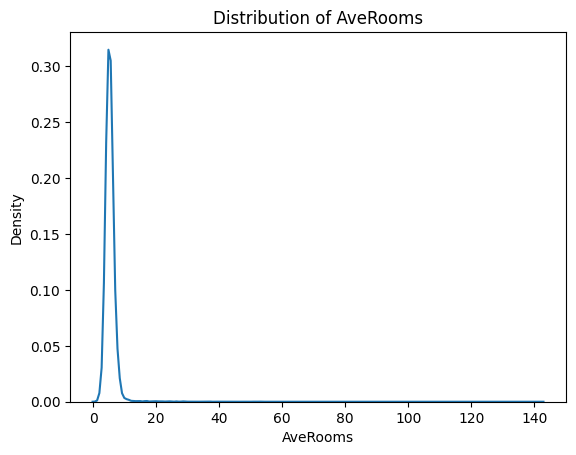

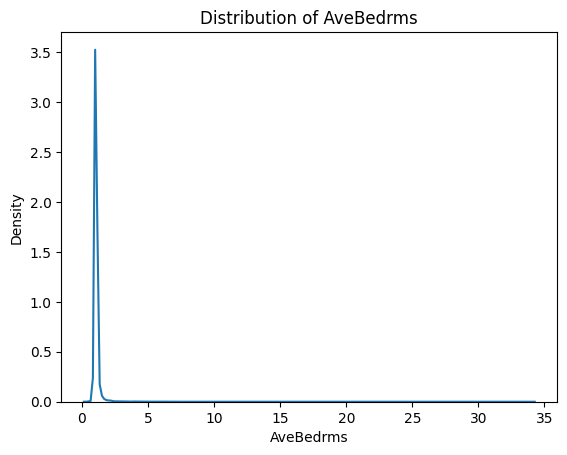

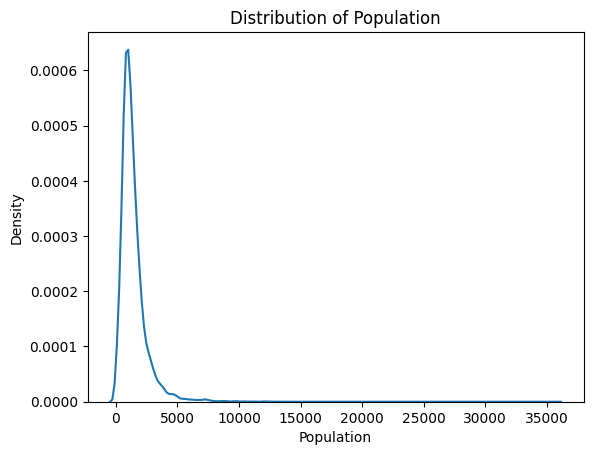

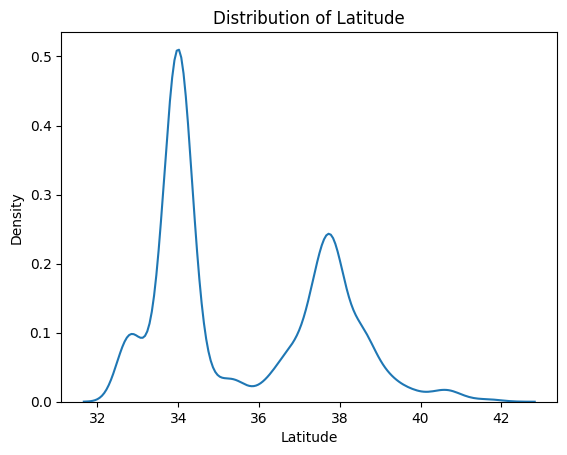

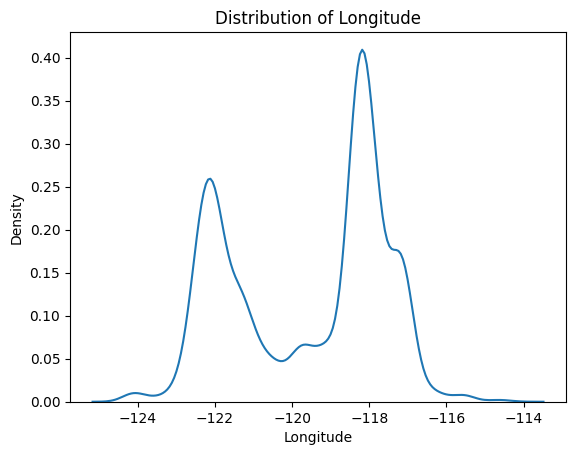

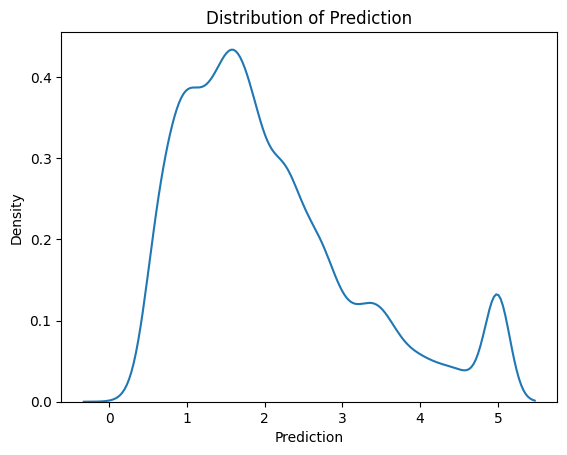

In [24]:
for column in df.columns:
    sns.kdeplot(data=df, x=column)
    plt.title(f"Distribution of {column}")
    plt.show()

In [ ]:
#Applying Log1 Tranformation for only 3 clms which seems to be more right skewed
import numpy as np
df['Population']=np.log1p(df['Population'])
df['AveBedrms']=np.log1p(df['AveBedrms'])
df['AveRooms']=np.log1p(df['AveRooms'])

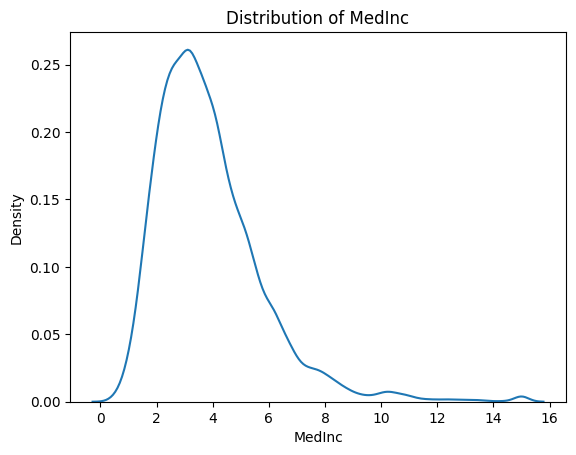

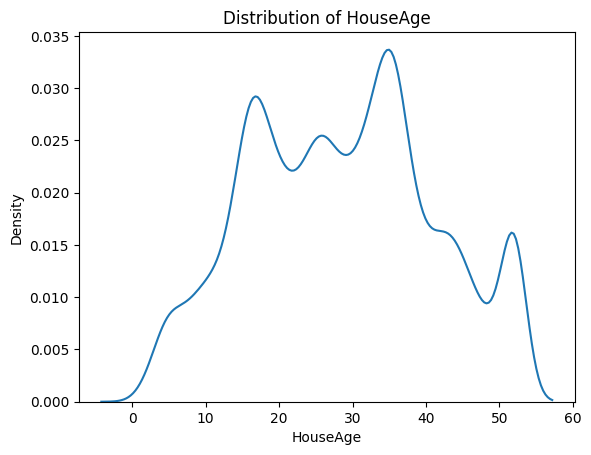

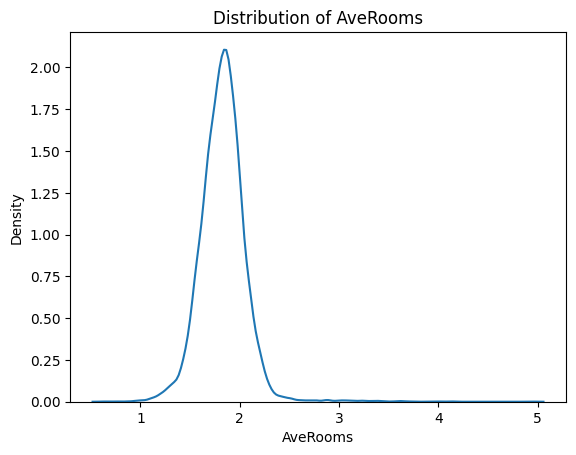

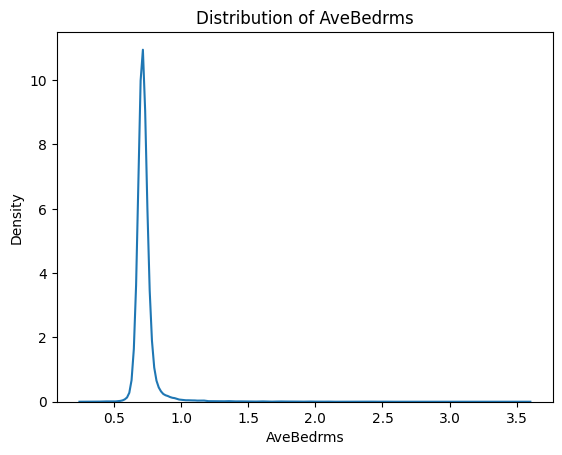

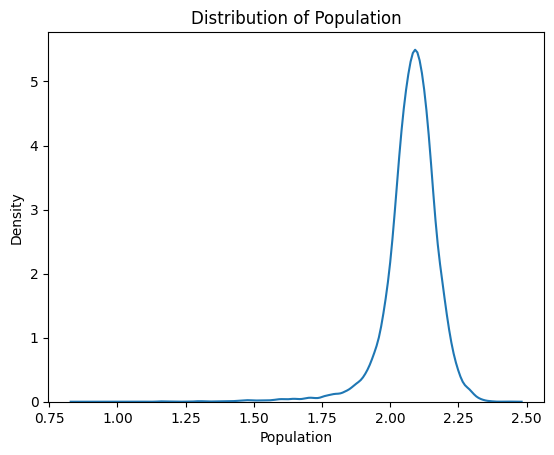

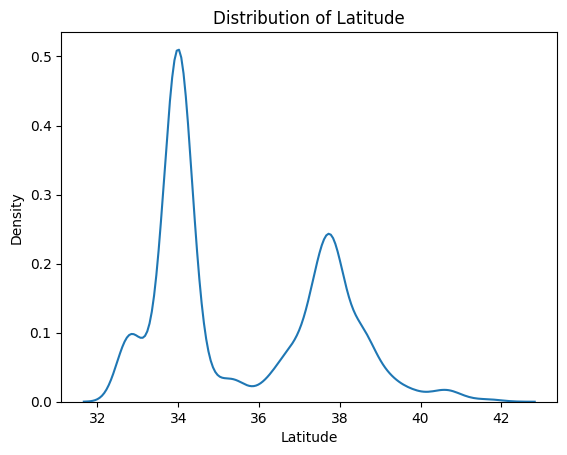

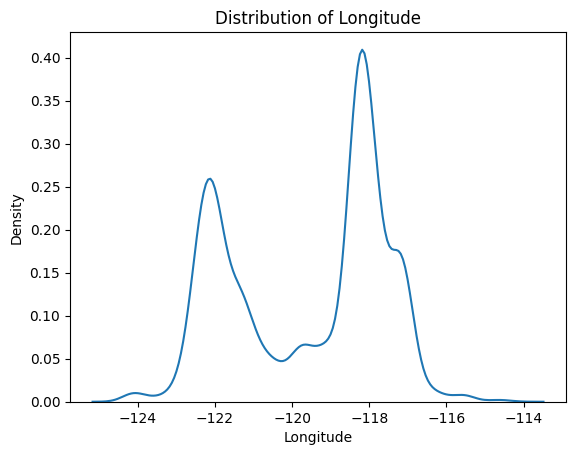

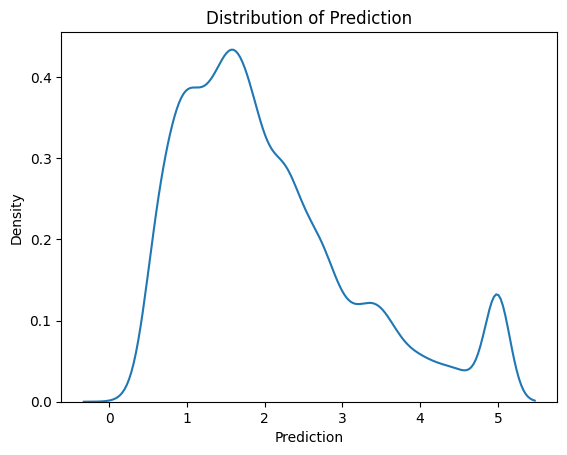

In [27]:
for column in df.columns:
    sns.kdeplot(data=df, x=column)
    plt.title(f"Distribution of {column}")
    plt.show()

In [33]:

# Features (X) aur Target (y)
X = df.iloc[:, :-1]  
y = df.iloc[:, -1]    

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      
    random_state=42     
)

In [35]:
model=LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)


print("R2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)

R2: 0.597263687811187
RMSE: 0.7264635430328562


Text(0.5, 1.0, 'Actual vs Predicted')

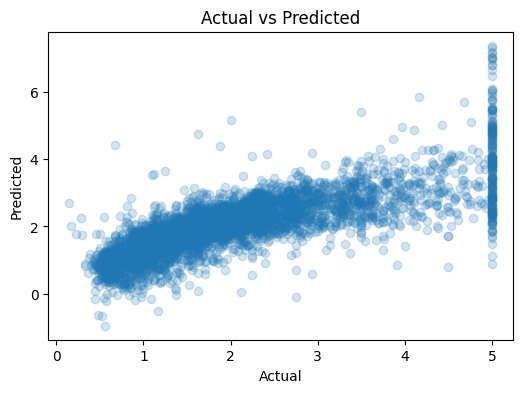

In [36]:
plt.figure(figsize=(6, 4))
plt.scatter(x=y_test,y=pred, alpha=0.2)
plt.xlabel('Actual')
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

R2 score usually tells us how well model predict house prices, as house prices are continous values so we annalize r2 score for House predictions.